<a href="https://colab.research.google.com/github/Bootcamp-DA-P3/Python_Analysis_Martin_Achraf/blob/main/Kiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Procesamiento, limpieza y representación gráfica de dataset en Python**

Realizado por
Martín Fernández Crespo y Achraf Azzouz con asistencia de Google Gemini Pro 3.1.


Dataset utilizado: Préstamos de Kiva (kiva_loans_42304.csv), adjunto en el Drive.

# 1- Importar dataset a notebook

In [1]:
import pandas as pd

df = pd.read_csv('kiva_loans_42304_rows.csv')
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,1175609,525.0,525.0,Personal Medical Expenses,Health,to buy medicines for her son’s treatment at th...,TJ,Tajikistan,Kanibadam,TJS,100.0,2016-10-27 04:54:27+00:00,2016-10-04 07:00:00+00:00,2016-11-05 02:14:03+00:00,14.0,18,#Health and Sanitation,female,monthly,2016-10-27
1,1056732,350.0,350.0,Butcher Shop,Food,to buy a refrigerator for his butcher shop,MX,Mexico,Ecatepec,MXN,294.0,2016-04-19 15:55:26+00:00,2016-03-31 07:00:00+00:00,2016-04-25 20:14:08+00:00,8.0,10,"#Elderly, #First Loan, #Health and Sanitation,...",male,monthly,2016-04-19
2,773348,225.0,225.0,Food,Food,to buy more raw ingredients for making food sn...,PH,Philippines,"Plaridel-Unidos, Plaridel, Misamis Occidental",PHP,126.0,2014-09-23 08:53:49+00:00,2014-09-19 07:00:00+00:00,2014-10-04 14:33:45+00:00,11.0,9,"volunteer_pick, volunteer_like, #Woman Owned Biz",female,irregular,2014-09-23
3,1076908,325.0,325.0,Farming,Agriculture,to purchase sacks of fertilizer,PH,Philippines,"Pagadian City, Zamboanga del Sur",PHP,126.0,2016-05-27 08:40:46+00:00,2016-05-10 07:00:00+00:00,2016-06-02 12:04:03+00:00,7.0,7,user_favorite,female,irregular,2016-05-27
4,680170,500.0,500.0,Poultry,Agriculture,To purchase more broiler chicks,ZW,Zimbabwe,Nyanga,USD,305.0,2014-03-06 10:29:22+00:00,2014-03-05 08:00:00+00:00,2014-04-02 01:31:55+00:00,8.0,11,"#Woman Owned Biz, #Parent, #Low-profit FP",female,irregular,2014-03-06


# 2- Análisis exploratorio rápido (shape, tipos y resumen estadístico)

In [2]:
df.shape
df.dtypes

,0
id,int64
funded_amount,float64
loan_amount,float64
activity,object
sector,object
use,object
country_code,object
country,object
region,object
currency,object


In [3]:
df.describe()

,id,funded_amount,loan_amount,partner_id,term_in_months,lender_count
count,4.230800e+04,42308.000000,42308.000000,42308.000000,42308.000000,42308.000000
mean,1.024360e+06,844.327905,844.327905,184.002104,14.124255,23.276023
std,1.920062e+05,1081.746992,1081.746992,99.689027,8.434400,28.493808
min,6.531060e+05,25.000000,25.000000,9.000000,2.000000,1.000000
25%,8.667138e+05,300.000000,300.000000,126.000000,8.000000,8.000000
50%,1.038604e+06,500.000000,500.000000,154.000000,14.000000,15.000000
75%,1.195408e+06,1000.000000,1000.000000,222.000000,14.000000,28.000000
max,1.338878e+06,50000.000000,50000.000000,528.000000,148.000000,1410.000000


Conversión de columnas de fecha

In [4]:
columnas_fecha = ['posted_time', 'disbursed_time', 'funded_time', 'date']
for col in columnas_fecha:
    df[col] = pd.to_datetime(df[col])

Captura de archivo csv

In [5]:
df_raw = pd.read_csv('kiva_loans_42304_rows.csv')
df = df_raw.copy()

Tipos de datos actualizados

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42308 entries, 0 to 42307
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  42308 non-null  int64  
 1   funded_amount       42308 non-null  float64
 2   loan_amount         42308 non-null  float64
 3   activity            42308 non-null  object 
 4   sector              42308 non-null  object 
 5   use                 42308 non-null  object 
 6   country_code        42308 non-null  object 
 7   country             42308 non-null  object 
 8   region              42308 non-null  object 
 9   currency            42308 non-null  object 
 10  partner_id          42308 non-null  float64
 11  posted_time         42308 non-null  object 
 12  disbursed_time      42308 non-null  object 
 13  funded_time         42308 non-null  object 
 14  term_in_months      42308 non-null  float64
 15  lender_count        42308 non-null  int64  
 16  tags

Resumen estadístico numérico clave

In [7]:
df[['funded_amount', 'loan_amount', 'term_in_months', 'lender_count']].describe()

,funded_amount,loan_amount,term_in_months,lender_count
count,42308.000000,42308.000000,42308.000000,42308.000000
mean,844.327905,844.327905,14.124255,23.276023
std,1081.746992,1081.746992,8.434400,28.493808
min,25.000000,25.000000,2.000000,1.000000
25%,300.000000,300.000000,8.000000,8.000000
50%,500.000000,500.000000,14.000000,15.000000
75%,1000.000000,1000.000000,14.000000,28.000000
max,50000.000000,50000.000000,148.000000,1410.000000


# 3 - Diagnóstico de problemas


1.   Valores faltantes por columna
2.   Detección de duplicados
3.   Revisión de valores únicos






In [8]:

print("Valores nulos por columna:\n", df.isnull().sum())


print("Filas duplicadas exactas:", df.duplicated().sum())


Valores nulos por columna:
 id                    0
funded_amount         0
loan_amount           0
activity              0
sector                0
use                   0
country_code          0
country               0
region                0
currency              0
partner_id            0
posted_time           0
disbursed_time        0
funded_time           0
term_in_months        0
lender_count          0
tags                  0
borrower_genders      0
repayment_interval    0
date                  0
dtype: int64
Filas duplicadas exactas: 0


Al tratarse de un dataset ya limpio, no se han encontrado problemas

# Transformación de fechas

In [9]:
columnas_fecha = ['posted_time', 'disbursed_time', 'funded_time', 'date']

Bucle para convertir cada columna de la lista al formato fecha de Pandas

In [10]:
for col in columnas_fecha:
    df[col] = pd.to_datetime(df[col], errors='coerce')

Verificación de los cambios realizados

In [11]:
print("Tipos de datos tras la conversión de fechas:")
print(df[columnas_fecha].dtypes)

Tipos de datos tras la conversión de fechas:
posted_time       datetime64[ns, UTC]
disbursed_time    datetime64[ns, UTC]
funded_time       datetime64[ns, UTC]
date                   datetime64[ns]
dtype: object


# Normalización de textos

In [12]:
columnas_texto = ['sector', 'activity', 'country', 'borrower_genders', 'repayment_interval']

Bucle para aplicar las transformaciones de texto a cada columna

In [13]:
for col in columnas_texto:
    df[col] = df[col].astype(str).str.lower().str.strip()

Verificación de cómo ha quedado una de las columnas (ejemplo: sector)

In [14]:
print("\nMuestra de los datos limpios en la columna 'sector':")
print(df['sector'].unique()[:5])


Muestra de los datos limpios en la columna 'sector':
['health' 'food' 'agriculture' 'retail' 'housing']


# Diagnóstico y Gestión de Outliers (Valores atípicos)

<Axes: >

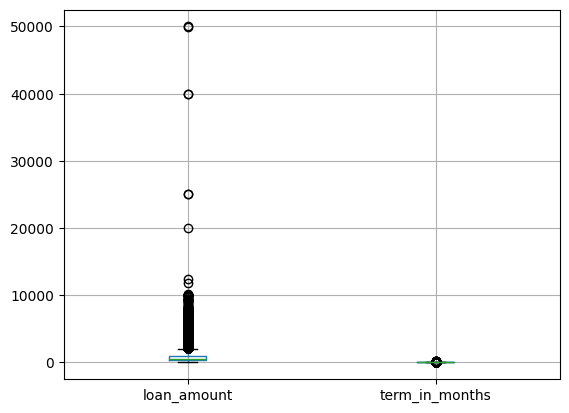

In [15]:
df.boxplot(column=['loan_amount', 'term_in_months'])

*Filtrado* de *Outliers*

Criterio documentado: Eliminamos préstamos con plazos mayores a 5 años (60 meses)

 cantidades superiores a 20.000$ por considerarse casos excepcionales que sesgarían el análisis

In [16]:
df_limpio = df[
    (df['term_in_months'] <= 60) &
    (df['loan_amount'] <= 20000)
].copy()


In [17]:
print("Dimensiones antes de limpiar outliers:", df.shape)


Dimensiones antes de limpiar outliers: (42308, 20)


In [18]:
print("Dimensiones tras limpiar outliers:", df_limpio.shape)

Dimensiones tras limpiar outliers: (42081, 20)


Paso 2: Crear Columnas Derivadas Útiles (Feature Engineering)
*Python* *texto en cursiva*

Extraer el año y mes en columnas separadas para facilitar gráficos temporales

In [19]:
df_limpio['año_prestamo'] = df_limpio['date'].dt.year
df_limpio['mes_prestamo'] = df_limpio['date'].dt.month


# Crear una categoría de riesgo o tamaño del préstamo de forma ultrarrápida con NumPy

In [20]:
import numpy as np
condiciones = [
    (df_limpio['loan_amount'] < 500),
    (df_limpio['loan_amount'] >= 500) & (df_limpio['loan_amount'] <= 2000),
    (df_limpio['loan_amount'] > 2000)
]
opciones = ['Pequeño', 'Mediano', 'Grande']

df_limpio['tamano_prestamo'] = np.select(condiciones, opciones, default='Desconocido')

# ¿Cuál es el promedio prestado por cada país, de mayor a menor? (Pandas)

In [21]:
resumen_pais = df_limpio.groupby('country')['loan_amount'].mean().sort_values(ascending=False)
print(resumen_pais.head())

country
congo            5496.875000
somalia          4900.000000
united states    4528.773585
turkey           4341.666667
israel           4012.500000
Name: loan_amount, dtype: float64


# Histograma para ver cómo se distribuyen los plazos de pago en Matplolib

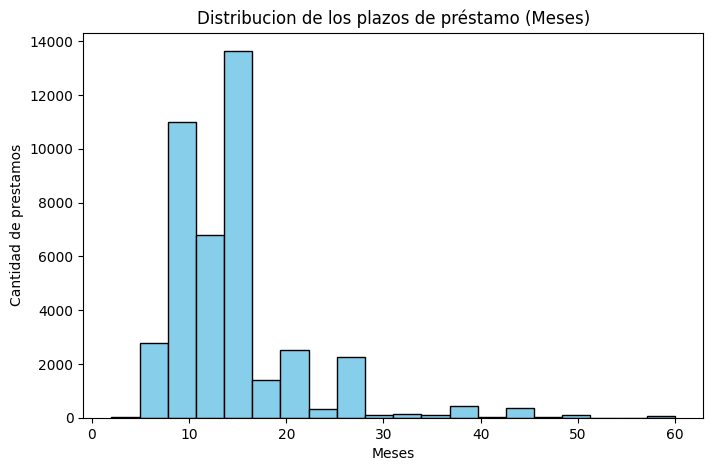

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(df_limpio['term_in_months'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribucion de los plazos de préstamo (Meses)')
plt.xlabel('Meses')
plt.ylabel('Cantidad de prestamos')
plt.show()

# Un Boxplot (diagrama de caja) para ver qué sectores piden más dinero y sus casos atípicos en Seaborn

/tmp/ipykernel_1357/151897048.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='sector', y='loan_amount', palette='viridis')


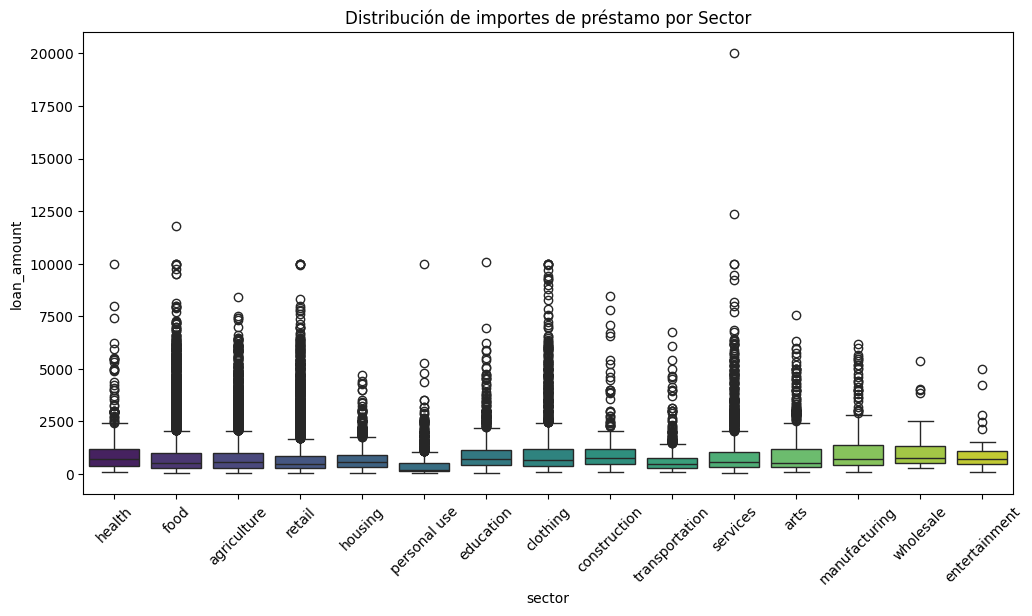

In [23]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_limpio, x='sector', y='loan_amount', palette='viridis')
plt.xticks(rotation=45) # Gira las etiquetas de texto del eje X para que se lean bien
plt.title('Distribución de importes de préstamo por Sector')
plt.show()

# Calcular el tiempo que tardó en financiarse el préstamo en días
### Restamos la fecha en que se financió (funded_time) menos cuando se publicó (posted_time)

In [25]:
df_limpio['funded_time'] = pd.to_datetime(df_limpio['funded_time'])
df_limpio['posted_time'] = pd.to_datetime(df_limpio['posted_time'])
df_limpio['dias_para_fondeo'] = (df_limpio['funded_time'] - df_limpio['posted_time']).dt.days

print("Nuevas columnas creadas. Muestra del cálculo de días:")
print(df_limpio[['posted_time', 'funded_time', 'dias_para_fondeo']].head(3))


Nuevas columnas creadas. Muestra del cálculo de días:
                posted_time               funded_time  dias_para_fondeo
0 2016-10-27 04:54:27+00:00 2016-11-05 02:14:03+00:00                 8
1 2016-04-19 15:55:26+00:00 2016-04-25 20:14:08+00:00                 6
2 2014-09-23 08:53:49+00:00 2014-10-04 14:33:45+00:00                11


# Relación entre lo que se pidió, lo que se financió y el plazo tomando solo una muestra (sample) de 1000 filas mediante la función Pair Plot

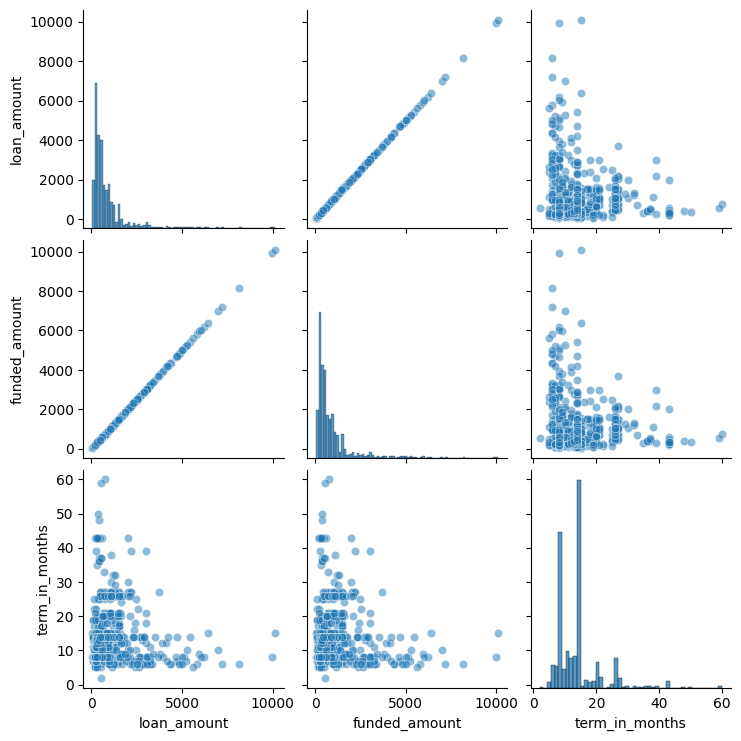

In [26]:
columnas_numericas = ['loan_amount', 'funded_amount', 'term_in_months']

sns.pairplot(df_limpio[columnas_numericas].sample(1000),
             kind='scatter',
             plot_kws={'alpha': 0.5}) # alpha hace los puntos tenga tranparencias para ver acumulaciones
plt.show()

# 1. Convertir los intervalos de pago a una escala numérica

In [27]:
mapeo_pago = {'bullet': 0, 'monthly': 1, 'irregular': 2}

df_limpio['repayment_interval_num'] = df_limpio['repayment_interval'].map(mapeo_pago)

# 2. Codificación del género
# Nota: En Kiva, si es un grupo, a veces dice "female, female, male".
# Usamos np.where para poner un 1 si la palabra 'female' aparece en la celda, y un 0 si no.


In [28]:
import numpy as np

In [29]:
df_limpio['grupo_mujeres'] = np.where(
    df_limpio['borrower_genders'].astype(str).str.contains('female'),
    1,
    0
)

print("\nComprobación de la codificación de pagos:")
print(df_limpio[['repayment_interval', 'repayment_interval_num']].drop_duplicates())



Comprobación de la codificación de pagos:
   repayment_interval  repayment_interval_num
0             monthly                       1
2           irregular                       2
13             bullet                       0


# 1. Pruebas automáticas (asserts) - Si algo está mal, el código dará error y se detendrá
# Validamos que no existan préstamos de cero o negativos

In [30]:
assert (df_limpio['loan_amount'] > 0).all(), "Error: Existen préstamos con valor 0 o negativo."


# Validamos que no se hayan duplicado los IDs durante el proceso

In [33]:
assert df_limpio['id'].is_unique, "Error: Hay identificadores de préstamo duplicados."

# 2. Exportar el dataset final

In [32]:
df_limpio.to_csv('kiva_loans_limpio_final.csv', index=False)
print("📦 Archivo 'kiva_loans_limpio_final.csv' guardado correctamente.")

📦 Archivo 'kiva_loans_limpio_final.csv' guardado correctamente.
